### Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
from xgboost import XGBClassifier

### Step 2: Load Dataset

In [6]:
df = pd.read_csv('./data/ad_10000records.csv')

In [7]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0
2,44.40,30.0,57877.15,172.83,Total 5thgeneration standardization,Reyesfurt,Female,Guadeloupe,2016-06-29 10:50:45,0
3,59.88,28.0,56180.93,207.17,Balanced empowering success,New Michael,Female,Zambia,2016-06-21 14:32:32,0
4,49.21,30.0,54324.73,201.58,Total 5thgeneration standardization,West Richard,Female,Qatar,2016-07-21 10:54:35,1


### Step 3: Exploring Data

In [25]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,61.660757,35.940100,53840.047721,177.759831,0.491700
std,15.704142,8.572973,13343.708718,40.820951,0.499956
min,32.600000,19.000000,13996.500000,105.220000,0.000000
25%,48.860000,29.000000,44052.302500,140.150000,0.000000
50%,59.590000,35.000000,56180.930000,178.920000,0.000000
75%,76.580000,42.000000,61840.260000,212.670000,1.000000
max,90.970000,60.000000,79332.330000,269.960000,1.000000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  10000 non-null  float64
 1   Age                       10000 non-null  float64
 2   Area Income               10000 non-null  float64
 3   Daily Internet Usage      10000 non-null  float64
 4   Ad Topic Line             10000 non-null  object 
 5   City                      10000 non-null  object 
 6   Gender                    10000 non-null  object 
 7   Country                   10000 non-null  object 
 8   Timestamp                 10000 non-null  object 
 9   Clicked on Ad             10000 non-null  int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 781.4+ KB


<Axes: xlabel='Clicked on Ad'>

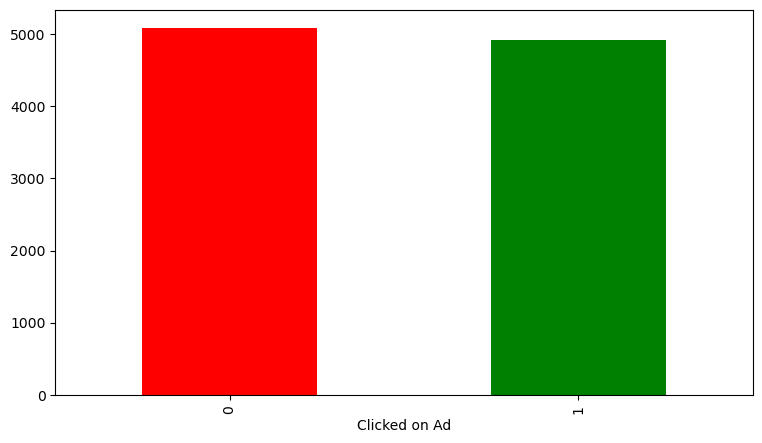

In [11]:
plt.figure(figsize=(9, 5))
df['Clicked on Ad'].value_counts().plot(kind='bar', color=['red', 'green'])

In [23]:
print('The click through rate is {}%'.format(df['Clicked on Ad'].sum()/len(df) * 100 ))
print('The not click through rate is {}%'.format((df['Clicked on Ad'] == 0).sum()/len(df) * 100 ))

The click through rate is 49.17%
The not click through rate is 50.83%


### Step 4: Feature Engineering

In [24]:
le = LabelEncoder()

In [45]:
object_list = list(df.select_dtypes(include='object').columns)

In [46]:
for obj in object_list:
    df[obj] = le.fit_transform(df[obj])

<Axes: >

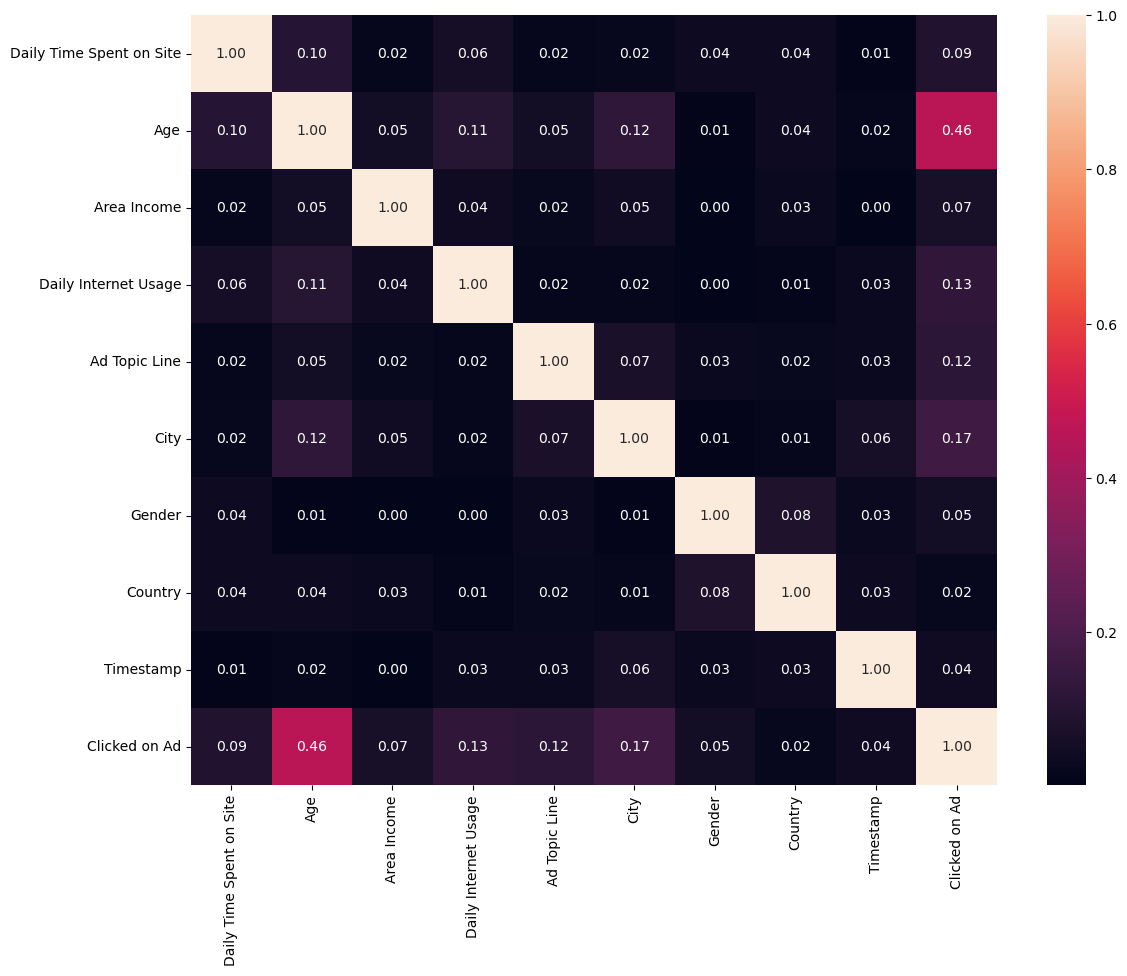

In [47]:
plt.figure(figsize=(13, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr().abs(),
    annot=True,
    fmt='.2f'
)

### Step 5: Preparing Data

In [49]:
# features = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Gender']]
features = df.drop(['Clicked on Ad'], axis=1)
target = df['Clicked on Ad']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Defining & Training Model

In [51]:
model = XGBClassifier(random_state=42)

In [52]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Step 7: Evaluate Model

In [53]:
y_pred = model.predict(X_test)

In [54]:
print('The model accuracy is', accuracy_score(y_test, y_pred))

The model accuracy is 0.8785
